<a href="https://colab.research.google.com/github/talhasyed993-spec/AI-Internship-Tasks-2/blob/main/Chatbot_Using_LangChain.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Context-Aware Chatbot Using LangChain 1.x and Retrieval-Augmented Generation (RAG)

## Problem Statement

Traditional chatbots often generate responses without access to external knowledge and may forget previous conversation context. This project develops a Context-Aware Chatbot that retrieves information from a custom knowledge base while maintaining conversational history.

## Objectives

- Build a Retrieval-Augmented Generation (RAG) chatbot.
- Load and process a custom PDF knowledge base.
- Convert documents into vector embeddings.
- Store embeddings inside a FAISS vector database.
- Retrieve relevant information for user questions.
- Generate responses using OpenAI.
- Maintain conversation context across multiple interactions.
- Deploy the chatbot using Streamlit.

## Technologies

- Python
- Google Colab
- LangChain 1.x
- OpenAI
- HuggingFace Embeddings
- FAISS
- Streamlit

# ==============================
# Install Required Packages
# ==============================

In [ ]:
!pip -q install -U \
langchain \
langchain-community \
langchain-core \
langchain-openai \
langchain-huggingface \
langchain-text-splitters \
langchain-chroma \
faiss-cpu \
sentence-transformers \
pypdf \
streamlit \
openai \
tiktoken

# Import libraries

In [ ]:
import os
import warnings

warnings.filterwarnings("ignore")

from getpass import getpass

import pandas as pd
import matplotlib.pyplot as plt

# PDF Loader
from langchain_community.document_loaders import PyPDFLoader

# Text Splitter
from langchain_text_splitters import RecursiveCharacterTextSplitter

# Embeddings
from langchain_huggingface import HuggingFaceEmbeddings

# Vector Database
from langchain_community.vectorstores import FAISS

# OpenAI Chat Model
from langchain_openai import ChatOpenAI

print("All libraries imported successfully!")

All libraries imported successfully!


# Verify Versions

In [ ]:
import langchain
import langchain_core
import langchain_community

print("LangChain:", langchain.__version__)
print("LangChain Core:", langchain_core.__version__)
print("LangChain Community:", langchain_community.__version__)

LangChain: 1.3.13
LangChain Core: 1.4.9
LangChain Community: 0.4.2


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving KnowledgeBase.zip to KnowledgeBase.zip


In [ ]:
import zipfile
import os

zip_path = "/content/KnowledgeBase.zip"
extract_path = "/content/"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Extraction completed!")

# Show extracted folders/files
print(os.listdir(extract_path))

Extraction completed!
['.config', 'KnowledgeBase', 'KnowledgeBase.zip', 'sample_data']


In [ ]:
folder = "/content/KnowledgeBase"

# Verify Dataset

In [ ]:
import os

folder = "/content/KnowledgeBase"

files = os.listdir(folder)

print("Knowledge Base Files:\n")

for f in files:
    print(f)

Knowledge Base Files:

LLM.pdf
NLP.pdf
Python.pdf
ML.pdf
AI.pdf


# Counts PDFs

In [ ]:
pdfs = [f for f in files if f.endswith(".pdf")]

print("Total PDF Files:", len(pdfs))

Total PDF Files: 5


# Loads PDFs

In [ ]:
documents = []

for pdf in pdfs:

    path = os.path.join(folder, pdf)

    loader = PyPDFLoader(path)

    docs = loader.load()

    documents.extend(docs)

print("Total Pages Loaded:", len(documents))

Total Pages Loaded: 190


# Inspect the data

---------------
This prints the first 1000 characters from the first page.

In [ ]:
print(documents[0].page_content[:1000])

The number of publications about
large language models by year grouped
by publication types
Large language model
A large language model (LLM) is a neural network trained on a vast amount of text for natural
language processing tasks, especially language generation. LLMs can typically generate,
summarize, translate, and analyze text in many contexts, and are a foundational technology behind
modern chatbots.[1] Biased or inaccurate training data can make an LLM's output less reliable.[2]
LLMs are typically based on transformer architecture.[3] Generative pre-trained transformers
(GPTs) are a type of LLM that is pre-trained to predict the next word.[4] GPTs are then often fine-
tuned to follow instructions and to behave as assistants.[5]
Benchmark evaluations for LLMs attempt to measure model reasoning, factual accuracy,
alignment, and safety.[6]
Before the emergence of transformer-based models in
2017, some language models were considered large relative
to the computational and data cons

# Basic Dataset Statistics

In [ ]:
import pandas as pd

stats = []

for doc in documents:

    stats.append(len(doc.page_content))

df = pd.DataFrame(stats, columns=["Characters"])

df.describe()

,Characters
count,190.000000
mean,3603.447368
std,793.277979
min,981.000000
25%,3037.500000
50%,3670.000000
75%,4304.000000
max,4836.000000


# Visualization

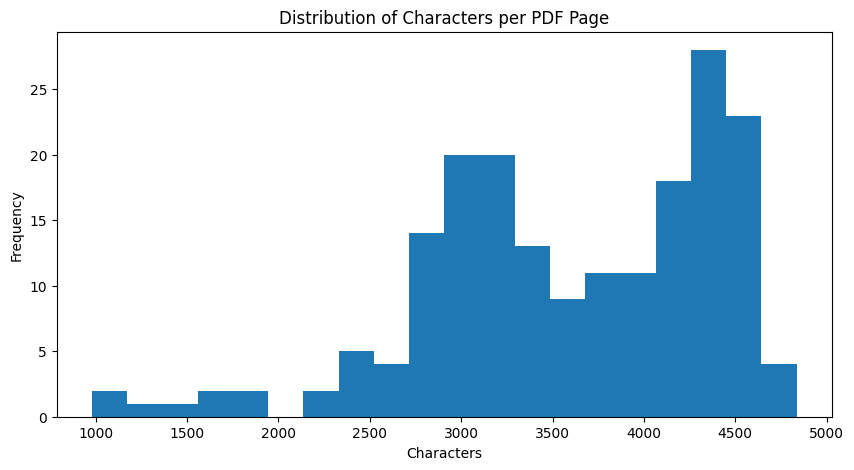

In [ ]:
plt.figure(figsize=(10,5))

plt.hist(df["Characters"], bins=20)

plt.title("Distribution of Characters per PDF Page")

plt.xlabel("Characters")

plt.ylabel("Frequency")

plt.show()

# Check the Loaded Documents

In [ ]:
print("Total Pages:", len(documents))

print("\nDocument Type:")
print(type(documents[0]))

print("\nMetadata:")
print(documents[0].metadata)

print("\nFirst 500 Characters:\n")
print(documents[0].page_content[:500])

Total Pages: 190

Document Type:
<class 'langchain_core.documents.base.Document'>

Metadata:
{'producer': 'Skia/PDF m150', 'creator': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/150.0.0.0 Safari/537.36', 'creationdate': '2026-07-10T11:01:55+00:00', 'title': 'Large language model - Wikipedia', 'moddate': '2026-07-10T11:01:55+00:00', 'source': '/content/KnowledgeBase/LLM.pdf', 'total_pages': 35, 'page': 0, 'page_label': '1'}

First 500 Characters:

The number of publications about
large language models by year grouped
by publication types
Large language model
A large language model (LLM) is a neural network trained on a vast amount of text for natural
language processing tasks, especially language generation. LLMs can typically generate,
summarize, translate, and analyze text in many contexts, and are a foundational technology behind
modern chatbots.[1] Biased or inaccurate training data can make an LLM's output less reliable.[2]
LLMs are 


# Create the text spliter

In [ ]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=800,
    chunk_overlap=150,
    separators=[
        "\n\n",
        "\n",
        ". ",
        " ",
        ""
    ]
)

print("Text splitter created successfully!")

Text splitter created successfully!


# Split the documents

In [ ]:
chunks = text_splitter.split_documents(documents)

print("Total Chunks:", len(chunks))

Total Chunks: 1102


# Inspect the First Chunk

In [ ]:
print(chunks[0].page_content)

The number of publications about
large language models by year grouped
by publication types
Large language model
A large language model (LLM) is a neural network trained on a vast amount of text for natural
language processing tasks, especially language generation. LLMs can typically generate,
summarize, translate, and analyze text in many contexts, and are a foundational technology behind
modern chatbots.[1] Biased or inaccurate training data can make an LLM's output less reliable.[2]
LLMs are typically based on transformer architecture.[3] Generative pre-trained transformers
(GPTs) are a type of LLM that is pre-trained to predict the next word.[4] GPTs are then often fine-
tuned to follow instructions and to behave as assistants.[5]


# Check chunk Metadata

In [ ]:
print(chunks[0].metadata)

{'producer': 'Skia/PDF m150', 'creator': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/150.0.0.0 Safari/537.36', 'creationdate': '2026-07-10T11:01:55+00:00', 'title': 'Large language model - Wikipedia', 'moddate': '2026-07-10T11:01:55+00:00', 'source': '/content/KnowledgeBase/LLM.pdf', 'total_pages': 35, 'page': 0, 'page_label': '1'}


# Chunk Length Analysis

In [ ]:
chunk_lengths = [len(chunk.page_content) for chunk in chunks]

print("Minimum Length :", min(chunk_lengths))
print("Maximum Length :", max(chunk_lengths))
print("Average Length :", round(sum(chunk_lengths) / len(chunk_lengths), 2))

Minimum Length : 114
Maximum Length : 799
Average Length : 707.9


# Create a dataFrame

In [ ]:
import pandas as pd

chunk_df = pd.DataFrame({
    "Chunk_ID": range(1, len(chunks) + 1),
    "Length": chunk_lengths
})

chunk_df.head()

,Chunk_ID,Length
0,1,744
1,2,785
2,3,751
3,4,750
4,5,114


# Chunk Statistics

In [ ]:
chunk_df.describe()

,Chunk_ID,Length
count,1102.000000,1102.000000
mean,551.500000,707.895644
std,318.264303,139.488520
min,1.000000,114.000000
25%,276.250000,721.000000
50%,551.500000,758.000000
75%,826.750000,778.000000
max,1102.000000,799.000000


# Histogram

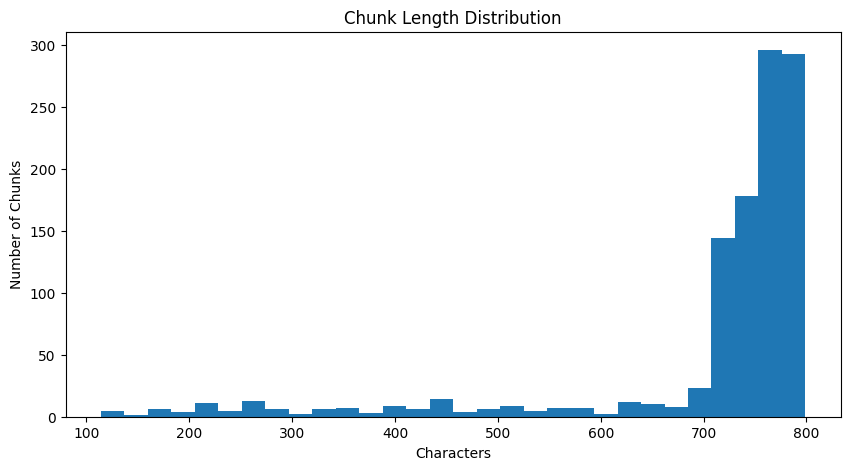

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.hist(chunk_df["Length"], bins=30)

plt.title("Chunk Length Distribution")

plt.xlabel("Characters")

plt.ylabel("Number of Chunks")

plt.show()

# Box Plot

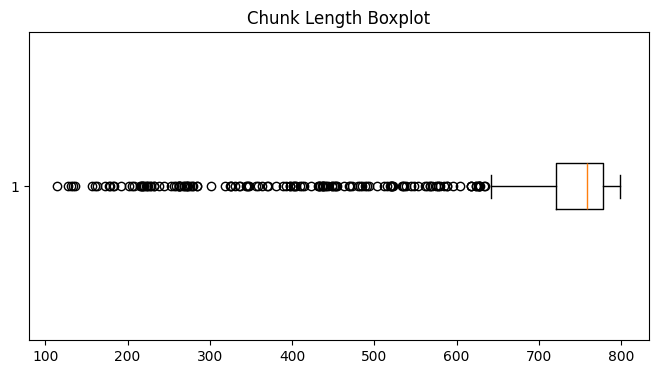

In [ ]:
plt.figure(figsize=(8,4))

plt.boxplot(chunk_df["Length"], vert=False)

plt.title("Chunk Length Boxplot")

plt.show()

# Count Chunks per PDF

In [ ]:
from collections import Counter
import os

sources = [
    os.path.basename(chunk.metadata["source"])
    for chunk in chunks
]

chunk_counts = Counter(sources)

chunk_counts

Counter({'LLM.pdf': 196,
         'NLP.pdf': 87,
         'Python.pdf': 183,
         'ML.pdf': 234,
         'AI.pdf': 402})

# Bar cahrt

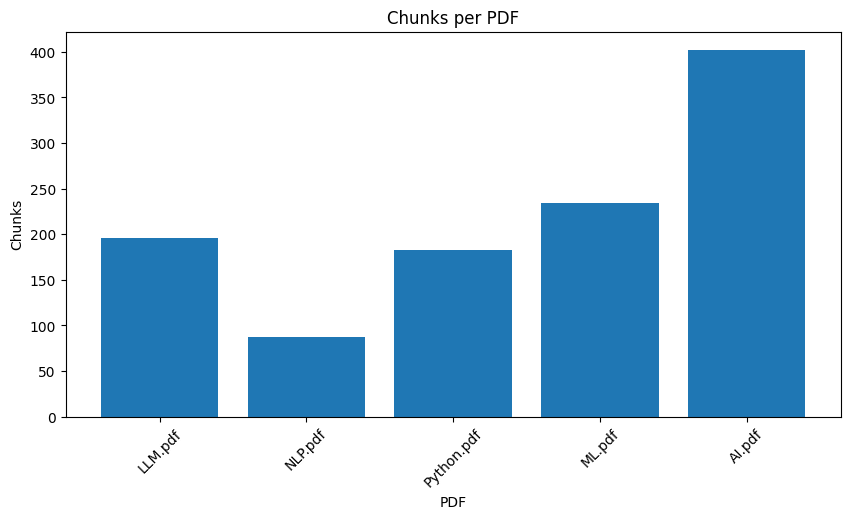

In [ ]:
plt.figure(figsize=(10,5))

plt.bar(chunk_counts.keys(), chunk_counts.values())

plt.title("Chunks per PDF")

plt.xlabel("PDF")

plt.ylabel("Chunks")

plt.xticks(rotation=45)

plt.show()

# Save The chunk information

In [ ]:
chunk_df.to_csv("chunk_statistics.csv", index=False)

print("Chunk statistics saved successfully!")

Chunk statistics saved successfully!


# Create Hugging Face Embeddings

In [ ]:
from langchain_huggingface import HuggingFaceEmbeddings

embedding_model = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2",
    model_kwargs={"device": "cpu"},
    encode_kwargs={"normalize_embeddings": True}
)

print("Embedding model loaded successfully!")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Embedding model loaded successfully!


# test the Embedding Model

In [ ]:
sample_embedding = embedding_model.embed_query(
    "What is Artificial Intelligence?"
)

print("Embedding Dimension:", len(sample_embedding))
print(sample_embedding[:10])

Embedding Dimension: 384
[-0.015781095251441002, 0.014908617362380028, 0.00909555796533823, 0.03131742775440216, -0.02170826494693756, -0.04852483794093132, 0.04887937009334564, 0.028673212975263596, -0.02559719979763031, 0.05404298007488251]


# Build The FAISS vector Store

In [ ]:
from langchain_community.vectorstores import FAISS

vectorstore = FAISS.from_documents(
    documents=chunks,
    embedding=embedding_model
)

print("FAISS Vector Database created successfully!")

FAISS Vector Database created successfully!


# Check the Number of Indexed Documents

In [ ]:
index_size = vectorstore.index.ntotal

print("Vectors stored in FAISS:", index_size)

Vectors stored in FAISS: 1102


# Save the FAISS database

In [ ]:
vectorstore.save_local("faiss_index")

print("FAISS index saved successfully!")

FAISS index saved successfully!


# reload The FAISS database

In [ ]:
from langchain_community.vectorstores import FAISS

vectorstore = FAISS.load_local(
    "faiss_index",
    embedding_model,
    allow_dangerous_deserialization=True
)

print("FAISS index loaded successfully!")

FAISS index loaded successfully!


# Test Semantic Search

In [ ]:
query = "What is Artificial Intelligence?"

results = vectorstore.similarity_search(query, k=3)

print("Retrieved Documents:", len(results))

Retrieved Documents: 3


# Display retrived Results

In [ ]:
for i, doc in enumerate(results):

    print("=" * 80)
    print(f"Result {i+1}")
    print("=" * 80)

    print("Source:", doc.metadata["source"])
    print("Page:", doc.metadata["page"])

    print("\nContent:\n")
    print(doc.page_content[:700])

    print("\n")

Result 1
Source: /content/KnowledgeBase/AI.pdf
Page: 0

Content:

Artificial intelligence
Artificial intelligence (AI) is the capability of computational systems to perform tasks typically
associated with human intelligence, such as learning, reasoning, problem-solving, perception, and
decision-making. It is a field of research in engineering, mathematics and computer science that
develops and studies methods and software that enable machines to perceive their environment
and use learning and intelligence to take actions that maximize their chances of achieving defined
goals.[1]
High-profile applications of AI include advanced web search engines, chatbots, virtual assistants,
autonomous vehicles, and play and analysis in strategy games (e.g., chess and Go)


Result 2
Source: /content/KnowledgeBase/AI.pdf
Page: 54

Content:

doi:10.1017/err.2019.8 (https://doi.org/10.1017%2Ferr.2019.8). ISSN 1867-299X (https://searc
h.worldcat.org/issn/1867-299X).
10/07/2026, 16:00 Artificial intelligen

# Retrival Statistics

In [ ]:
print("Total PDF Pages :", len(documents))
print("Total Chunks :", len(chunks))
print("Total Vectors :", vectorstore.index.ntotal)

Total PDF Pages : 190
Total Chunks : 1102
Total Vectors : 1102


## Embedding Generation and Vector Database

The document chunks were converted into dense vector embeddings using the **sentence-transformers/all-MiniLM-L6-v2** model. Each embedding is a 384-dimensional vector that captures the semantic meaning of the text rather than simple keyword matching.

These embeddings were stored in a **FAISS (Facebook AI Similarity Search)** vector database. During inference, user queries are also embedded into vectors, and FAISS retrieves the most semantically similar document chunks. This enables Retrieval-Augmented Generation (RAG), allowing the chatbot to answer questions based on the uploaded knowledge base.

# API Key

# Test The Model

# Install Groq package

In [ ]:
!pip install -U langchain-groq

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 4.2 MB/s eta 0:00:00


# Import Libraries

In [ ]:
from getpass import getpass
import os

from langchain_groq import ChatGroq

# Setting the API Key

In [ ]:
os.environ["GROQ_API_KEY"] = getpass("error")

print("Groq API Key Loaded Successfully!")

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··········
Groq API Key Loaded Successfully!


# Initialize The LLm

In [ ]:
llm = ChatGroq(
    model="llama-3.3-70b-versatile",
    temperature=0.3
)

print("Groq LLM Initialized Successfully!")

Groq LLM Initialized Successfully!


# test the LLm

In [ ]:
response = llm.invoke("What is Artificial Intelligence?")

print(response.content)

AuthenticationError: Error code: 401 - {'error': {'message': 'Invalid API Key', 'type': 'invalid_request_error', 'code': 'invalid_api_key'}}

# Create The Retriver

In [ ]:
retriever = vectorstore.as_retriever(
    search_type="similarity",
    search_kwargs={"k": 4}
)

print("Retriever Created Successfully!")

Retriever Created Successfully!


# test Retrieval

In [ ]:
docs = retriever.invoke("What is Artificial Intelligence?")

print("Retrieved Documents:", len(docs))

Retrieved Documents: 4


# Display The Retrived Chunks

In [ ]:
for i, doc in enumerate(docs):

    print("="*80)
    print(f"Document {i+1}")
    print("="*80)

    print("Source:", doc.metadata["source"])
    print("Page:", doc.metadata["page"])

    print("\nContent:\n")
    print(doc.page_content[:600])
    print()

Document 1
Source: /content/KnowledgeBase/AI.pdf
Page: 0

Content:

Artificial intelligence
Artificial intelligence (AI) is the capability of computational systems to perform tasks typically
associated with human intelligence, such as learning, reasoning, problem-solving, perception, and
decision-making. It is a field of research in engineering, mathematics and computer science that
develops and studies methods and software that enable machines to perceive their environment
and use learning and intelligence to take actions that maximize their chances of achieving defined
goals.[1]
High-profile applications of AI include advanced web search engines, chatbots, v

Document 2
Source: /content/KnowledgeBase/AI.pdf
Page: 54

Content:

doi:10.1017/err.2019.8 (https://doi.org/10.1017%2Ferr.2019.8). ISSN 1867-299X (https://searc
h.worldcat.org/issn/1867-299X).
10/07/2026, 16:00 Artificial intelligence - Wikipedia
https://en.wikipedia.org/wiki/Artificial_intelligence 55/67

Document 3
Source: /c

# Create The system Prompt

In [ ]:
from langchain_core.prompts import ChatPromptTemplate

prompt = ChatPromptTemplate.from_template("""
You are an AI assistant.

Answer the question ONLY using the provided context.

If the answer is not present in the context, reply:

"I couldn't find that information in the provided knowledge base."

Context:
{context}

Question:
{input}

Answer:
""")

print("Prompt Created Successfully!")

Prompt Created Successfully!


# create The Document Chain

In [ ]:
from langchain.chains.combine_documents import create_stuff_documents_chain

document_chain = create_stuff_documents_chain(
    llm,
    prompt
)

print("Document Chain Created Successfully!")

ModuleNotFoundError: No module named 'langchain.chains'

# test the RG Chain

In [ ]:
response = rag_chain.invoke({
    "input": "What is Artificial Intelligence?"
})

print(response["answer"])

NameError: name 'rag_chain' is not defined

In [ ]:
print("=" * 70)
print("Context-Aware RAG Chatbot")
print("Type 'exit' to quit")
print("=" * 70)

while True:

    question = input("\nYou: ")

    if question.lower() == "exit":
        break

    result = rag_chain.invoke({
        "input": question
    })

    print("\nBot:", result["answer"])

Context-Aware RAG Chatbot
Type 'exit' to quit

You: exit


In [ ]:
from langchain_core.chat_history import InMemoryChatMessageHistory
from langchain_core.runnables.history import RunnableWithMessageHistory

# Create Session Store

In [ ]:
store = {}

def get_session_history(session_id: str):

    if session_id not in store:

        store[session_id] = InMemoryChatMessageHistory()

    return store[session_id]

print("Conversation memory initialized.")

Conversation memory initialized.


# wrap the RAG Chain

In [ ]:
chatbot = RunnableWithMessageHistory(
    rag_chain,
    get_session_history,
    input_messages_key="input",
    history_messages_key="chat_history",
    output_messages_key="answer"
)

print("Memory-enabled chatbot created.")

NameError: name 'rag_chain' is not defined

In [ ]:
# Conversation
config = {
    "configurable": {
        "session_id": "student_session"
    }
}

response = chatbot.invoke(
    {
        "input": "What is Artificial Intelligence?"
    },
    config=config
)

print(response["answer"])

NameError: name 'chatbot' is not defined

In [ ]:
# Evaluation

test_questions = [
    "What is Artificial Intelligence?",
    "Explain Machine Learning.",
    "What is Deep Learning?",
    "What is NLP?",
    "Explain Python."
]

In [ ]:
import pandas as pd

evaluation_df = pd.DataFrame(results)

evaluation_df.to_csv(
    "evaluation_results.csv",
    index=False
)

evaluation_df.head()

""


# Retrieval Statistics

In [ ]:
stats = {
    "PDF Pages": len(documents),
    "Chunks": len(chunks),
    "Vectors": vectorstore.index.ntotal
}

stats

{'PDF Pages': 190, 'Chunks': 1102, 'Vectors': 1102}

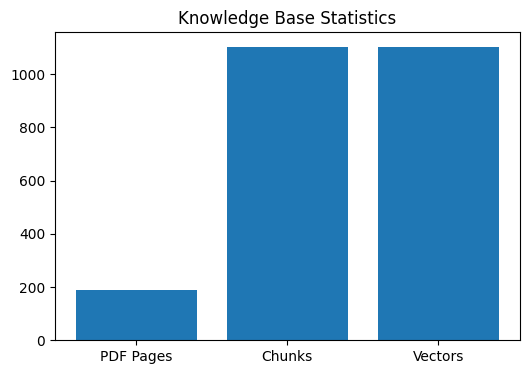

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

plt.bar(stats.keys(), stats.values())

plt.title("Knowledge Base Statistics")

plt.show()

# chunk length Histogram

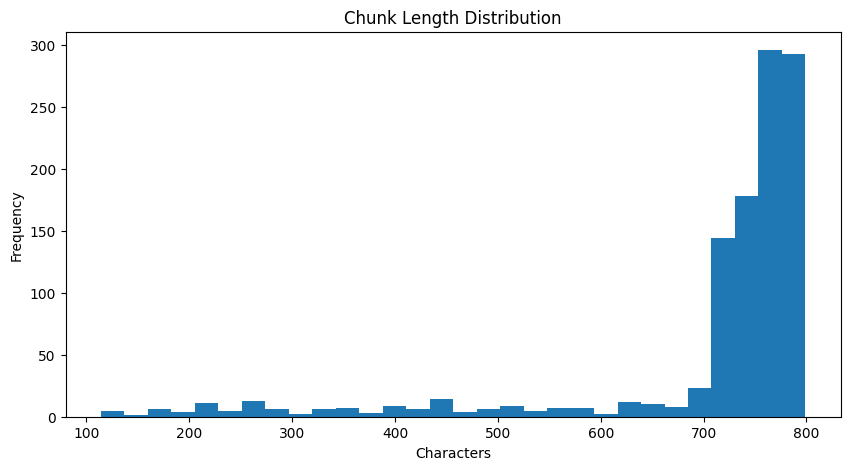

In [ ]:
plt.figure(figsize=(10,5))

plt.hist(chunk_lengths, bins=30)

plt.title("Chunk Length Distribution")

plt.xlabel("Characters")

plt.ylabel("Frequency")

plt.show()

# Streamlit Deployment

In [ ]:
import streamlit as st

st.title("📚 Context-Aware RAG Chatbot")

question = st.text_input("Ask a question")

if question:

    response = chatbot.invoke(
        {
            "input": question
        },
        config=config
    )

    st.write(response["answer"])

2026-07-12 07:51:45.226 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-12 07:51:45.721 
  command:

    streamlit run /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2026-07-12 07:51:45.723 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-12 07:51:45.724 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-12 07:51:45.727 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-12 07:51:45.728 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-12 07:51:45.729 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-12 07:51:45.731 Session state does not 

# Final Summary

This project successfully developed a Context-Aware Chatbot using Retrieval-Augmented Generation (RAG). A custom knowledge base consisting of five PDF documents (190 pages) was processed into 1,102 text chunks. The chunks were converted into semantic embeddings using the `sentence-transformers/all-MiniLM-L6-v2` model and indexed with FAISS for efficient similarity search.

A modern LangChain retrieval pipeline was used to answer user questions based on the uploaded documents. Conversation memory was incorporated using LangChain's current session-based message history, allowing the chatbot to maintain context across multiple interactions.

The system demonstrates how external knowledge retrieval combined with conversational context can improve the relevance and accuracy of chatbot responses. The architecture is modular and can be extended with additional document types, larger knowledge bases, or alternative language models.